Here tensorflow library is used for CNN by Google.

In [1]:
import cv2
import numpy as np
import os
import zipfile

from google.colab.patches import cv2_imshow
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path =  '/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/10_Image_Classification_usingCNN/homer_bart_1.zip'

In [3]:
z_object = zipfile.ZipFile(path, mode= 'r')
z_object.extractall('./')
z_object.close()

In [4]:
ls


drive/  homer_bart_1/  __MACOSX/  sample_data/


In [5]:
# Train  CNN using certain images of homer and bart

In [6]:
#os.path.join(directory, 'bart59.bmp')

In [7]:
directory = '/content/homer_bart_1'
sorted(os.listdir(directory))

['.DS_Store',
 'bart1.bmp',
 'bart10.bmp',
 'bart100.bmp',
 'bart101.bmp',
 'bart102.bmp',
 'bart103.bmp',
 'bart104.bmp',
 'bart105.bmp',
 'bart106.bmp',
 'bart108.bmp',
 'bart109.bmp',
 'bart11.bmp',
 'bart110.bmp',
 'bart111.bmp',
 'bart112.bmp',
 'bart113.bmp',
 'bart114.bmp',
 'bart115.bmp',
 'bart116.bmp',
 'bart117.bmp',
 'bart118.bmp',
 'bart119.bmp',
 'bart12.bmp',
 'bart120.bmp',
 'bart121.bmp',
 'bart122.bmp',
 'bart123.bmp',
 'bart124.bmp',
 'bart125.bmp',
 'bart126.bmp',
 'bart127.bmp',
 'bart128.bmp',
 'bart13.bmp',
 'bart130.bmp',
 'bart131.bmp',
 'bart132.bmp',
 'bart133.bmp',
 'bart134.bmp',
 'bart135.bmp',
 'bart136.bmp',
 'bart137.bmp',
 'bart138.bmp',
 'bart139.bmp',
 'bart14.bmp',
 'bart141.bmp',
 'bart142.bmp',
 'bart143.bmp',
 'bart144.bmp',
 'bart145.bmp',
 'bart146.bmp',
 'bart147.bmp',
 'bart148.bmp',
 'bart149.bmp',
 'bart15.bmp',
 'bart150.bmp',
 'bart151.bmp',
 'bart153.bmp',
 'bart154.bmp',
 'bart155.bmp',
 'bart156.bmp',
 'bart157.bmp',
 'bart158.bmp',
 '

In [8]:
# joined
files = [os.path.join(directory, f) for f in sorted(os.listdir(directory))]
#files # This is actually a list.
type(files)

list

In [9]:
 # Converting images to array
 height, width = 128, 128

In [10]:
# 128* 128*3  # number of neurons at the input layer, if it is coloured.
# for gray scale : no.of neurons: 128*128*1

### Convert all the images to gray scale and same pixel :128*128.

---



In [11]:
images = []
classes = []
for im_path in files:
  try:
    image = cv2.imread(im_path)
    H,W = image.shape[:2]
  except:
    continue

  print(f"The size of the image before resizing :{image.shape}")
  image = cv2.resize(image, (width, height))
  image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  cv2_imshow(image)
  print(f"The size of the image after resizing :{image.shape}")

  image = image.ravel()
  print(f"After transforming to 1D array : {image.shape}")
  images.append(image)

  print(os.path.basename(os.path.normpath(im_path)))
  image_name = os.path.basename(os.path.normpath(im_path))
  if image_name.startswith('b'):
    class_name = 0
  else:
    class_name = 1
  classes.append(class_name)
  print(f"The above image is of class : {class_name} \n\n\n")


Output hidden; open in https://colab.research.google.com to view.

In [12]:
#cv2.imread(files[2])

In [13]:
#cv2.imread(files[4])

In [14]:
images

[array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 128, 123, 124], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 2

In [15]:
classes


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [16]:
x = np.asarray(images)
y = np.asarray(classes)

In [17]:
print(type(x))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [18]:
print(x.shape)
print(y.shape)

(269, 16384)
(269,)


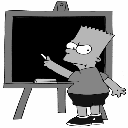

In [19]:
sample_img = x[1]
cv2_imshow(sample_img.reshape(width, height))

### Normalization:
Normalization & Standardization

Normalization is used to bring all features to a similar scale so that no feature dominates the model.
Example: age (20–70) vs salary (20,000–200,000).
Without scaling, salary has a much larger magnitude and contributes more to the model output, even if it is not more important.

Why we normalize:

Prevents large-scale features from dominating.

Makes gradient descent faster and more stable.

Improves performance of distance-based models (kNN, k-Means, SVM RBF, PCA).

Reduces numerical instability.

Prevents activation functions from saturating.

Common methods:

* Min-Max Scaling (Used when there is no outliers.)
* z normalization/ z-scoring/standardization.


Normalization helps ensure balanced feature contribution and smoother learning.

In [20]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [21]:
np.unique(y, return_counts=True)

(array([0, 1]), array([160, 109]))

In [22]:
x[0].max(), x[0].min()

(np.uint8(255), np.uint8(0))

In [23]:
# since we dont have any outliers, Iam going for minmax scaling.
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X = sc.fit_transform(x)

In [24]:
X[0].max(), X[0].min()

(np.float64(1.0000000000000002), np.float64(0.0))

### Train test split.

In [26]:
from sklearn.model_selection import  train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 101)

In [31]:
print(X_train.shape)
print(y_train.shape)

(215, 16384)
(215,)


### Building and Training the CNN.

* At input layer
* At hidden layers : 16384/2 + 1

In [32]:
network1 = tf.keras.models.Sequential()
network1.add(tf.keras.layers.Dense(input_shape = (16384,), units = 8193, activation='relu'))  # input layer
network1.add(tf.keras.layers.Dense(units=8193, activation='relu')) # hidden layer
network1.add(tf.keras.layers.Dense(units=1, activation='sigmoid')) # Output layer




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
network1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Next step, Compile the optimizer.
# Need to specify the optimizer, That is the algorithm to optimize the weights.

In [37]:
network1.compile(optimizer= 'Adam', loss='binary_crossentropy', metrics= ['accuracy'])

In [38]:
history = network1.fit(X_train, y_train, epochs= 75)

Epoch 1/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4641 - loss: 161.5041
Epoch 2/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.4258 - loss: 7.8864
Epoch 3/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.5333 - loss: 1.6532
Epoch 4/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.5706 - loss: 1.8220
Epoch 5/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5466 - loss: 2.0951
Epoch 6/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5904 - loss: 1.2690
Epoch 7/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5542 - loss: 0.7289
Epoch 8/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5821 - loss: 0.6823
Epoch 9/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5728 - loss: 0.6852
Epoch 10/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.6006 - loss: 0.6493
Epoch 11/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.7586 - loss: 0.6042
Epoch 12/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5852 - loss: 0.6806
Epoch 13/75

### Evaluating the neural network

In [39]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

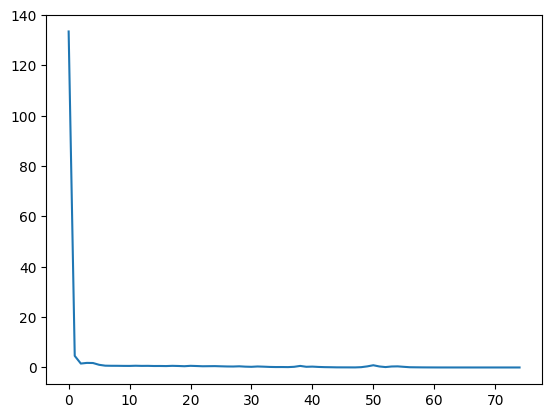

In [43]:
plt.plot(history.history['loss'])

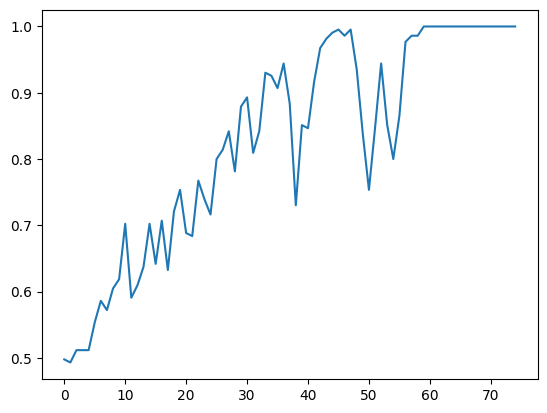

In [44]:
plt.plot(history.history['accuracy'])

In [47]:
predictions = network1.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step


In [48]:
predictions

array([[9.9309301e-01],
       [5.1013953e-03],
       [9.8851871e-01],
       [8.6638965e-03],
       [8.3646573e-02],
       [9.9969953e-01],
       [4.9685203e-03],
       [9.9998784e-01],
       [9.5278782e-01],
       [5.6255911e-03],
       [1.2323172e-04],
       [9.9269640e-01],
       [2.3195483e-03],
       [3.4480374e-02],
       [7.9061192e-01],
       [1.5726684e-02],
       [6.6048675e-04],
       [3.1383347e-03],
       [1.9567488e-02],
       [4.8100719e-01],
       [9.2918676e-01],
       [8.3906998e-05],
       [4.8710108e-01],
       [1.4804272e-02],
       [3.5886856e-05],
       [4.3971026e-01],
       [1.4622847e-05],
       [9.4552153e-01],
       [5.5337179e-04],
       [1.3251079e-03],
       [9.7256243e-01],
       [7.1659952e-01],
       [1.8417317e-05],
       [1.6275616e-01],
       [9.8346584e-02],
       [2.5751439e-04],
       [1.5997516e-03],
       [1.5530534e-03],
       [5.5519998e-04],
       [2.7199668e-01],
       [7.4541628e-01],
       [5.452949

In [52]:
predictions = predictions > 0.5
predictions

array([[ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False]])

In [54]:
y_test

array([1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 0])

In [60]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [58]:
accuracy_score(y_test, predictions)

0.6851851851851852

In [59]:
confusion_matrix(y_test, predictions)

array([[25,  5],
       [12, 12]])

In [61]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.68      0.83      0.75        30
           1       0.71      0.50      0.59        24

    accuracy                           0.69        54
   macro avg       0.69      0.67      0.67        54
weighted avg       0.69      0.69      0.67        54



In [62]:
# Saving and Loading the trained network

### Save

In [65]:
model_jason = network1.to_json()
with open('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/10_Image_Classification_usingCNN/network1.jason','w') as jason_file:
  jason_file.write(model_jason)


In [66]:
from keras.models import save_model

save_model(network1,'/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/10_Image_Classification_usingCNN/weights.hdf5')

### Load the model

In [67]:

with open('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/10_Image_Classification_usingCNN/network1.jason') as jason_file:
  jason_saved_model = jason_file.read()


In [68]:
jason_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 16384], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 8193, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null

In [69]:
network_loaded = tf.keras.models.model_from_json(jason_saved_model)
network_loaded.load_weights('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/10_Image_Classification_usingCNN/weights.hdf5')
# compile
network_loaded.compile(optimizer= 'Adam', loss='binary_crossentropy', metrics= ['accuracy'])

In [70]:
network_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

### Testing for new image.

In [74]:
newImage = X_test[10]
X_test[10].shape

(16384,)

In [80]:
testImage = sc.inverse_transform(newImage.reshape(1,-1))
testImage

array([[255., 255., 255., ..., 255., 255., 255.]])

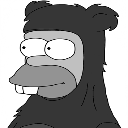

In [81]:
cv2_imshow(testImage.reshape(width, height))

In [85]:
if network_loaded.predict(testImage)[0][0] < 0.5:
  print("Bart")
else:
  print('Homer')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Bart
